# Calculate Greenspace Index for Philadelhpia
NDVI + Park Proximity + Tree Canopy Coverage

### 1. Import nessecary modules

In [27]:
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
from rasterstats import zonal_stats
import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# After downloading the NDVI raster from the previous notebook, set the file path here
ndvi_path = "../../data/philly_ndvi_2024_summer_fixed.tif"

# Load Philadelphia boundary file
phillygdf = gpd.read_file("../../data/City_Limits.geojson")

In [29]:
#Change CRS to match raster
phillygdf = phillygdf.to_crs("EPSG:2272")

In [30]:
# Verify the download
with rio.open(ndvi_path) as src:
    # clip to Philly boundary
    out_image, out_transform = mask(
        src,
        phillygdf.geometry,
        crop=True,
        nodata = np.nan
    )
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": np.nan
    })
    with rio.open("../../data/philly_ndvi_2024_summer_fixed_clipped.tif", "w", **out_meta) as dest:
        dest.write(out_image)



## 2. Census Tract Level Analysis

In [93]:
# Load Philly census tracts ACS 2022 
import pygris 
tracts = gpd.read_file("../../data/philly_neighborhoods.geojson")
# Change CRS to match raster
tracts = tracts.to_crs("EPSG:2272")

In [32]:
# Calculate zonal statistics for each census tract 
ndvi_stats = zonal_stats(
    tracts.geometry,
    "../../data/philly_ndvi_2024_summer_fixed_clipped.tif",
    stats=['mean', 'median', 'std', 'count'],
    nodata = np.nan
)

In [94]:
# Add stats to tracts GeoDataFrame
tracts['ndvi_mean'] = [stat['mean'] for stat in ndvi_stats]
tracts['ndvi_median'] = [stat['median'] for stat in ndvi_stats]
tracts['ndvi_std'] = [stat['std'] for stat in ndvi_stats]
tracts['ndvi_count'] = [stat['count'] for stat in ndvi_stats]

In [44]:
 # Summary statistics
print(f"\nNDVI Statistics Summary by Census Tract:")
print(tracts['ndvi_mean'].describe())
print(f"\nTracts with valid data: {(~tracts['ndvi_mean'].isna()).sum()}")
print(f"Tracts with NaN (water/no data): {tracts['ndvi_mean'].isna().sum()}")


NDVI Statistics Summary by Census Tract:
count    158.000000
mean       0.174365
std        0.073124
min        0.047595
25%        0.122232
50%        0.160920
75%        0.226999
max        0.410180
Name: ndvi_mean, dtype: float64

Tracts with valid data: 158
Tracts with NaN (water/no data): 0


### 2.1 Normalize NDVI values for easier interpretation scale (0-1)

In [95]:
ndvi_min = tracts['ndvi_mean'].min()
ndvi_max = tracts['ndvi_mean'].max()

tracts['ndvi_score'] = (tracts['ndvi_mean'] - ndvi_min) / (ndvi_max - ndvi_min)


In [96]:
# Save intermediate results
tracts.to_file('../../data/tracts_with_ndvi.geojson', driver='GeoJSON')

print(f"NDVI scores normalized to 0-1 scale")
print(f"Mean score: {tracts['ndvi_score'].mean():.3f}")


NDVI scores normalized to 0-1 scale
Mean score: 0.350


### 2.2 Let's visualize the NDVI scores across census tracts

In [47]:
import hvplot.pandas


tracts_plot = tracts.copy() # Create a copy for plotting
tracts_plot = tracts_plot.to_crs('EPSG:4326')  # Convert to lat/lon for hvplot

In [48]:
# Interactive choropleth
ndvi_map = tracts_plot.hvplot(
    c='ndvi_score',
    cmap='YlGn',
    hover_cols=['GEOID', 'ndvi_mean', 'ndvi_score'],
    tiles='CartoLight',
    alpha=0.7,
    frame_width=600,
    frame_height=500,
    title='NDVI Score by Census Tract - Philadelphia',
    clabel='NDVI Score'
)

ndvi_map

:Overlay
   .Tiles.I    :Tiles   [x,y]
   .Polygons.I :Polygons   [x,y]   (ndvi_score,ndvi_mean)

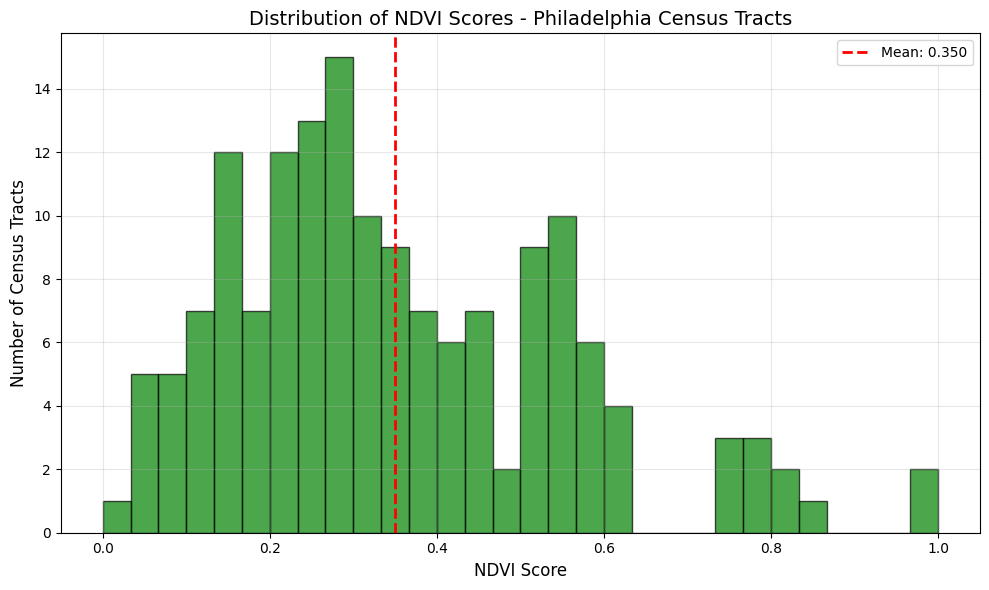

In [49]:
## Histogram
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(tracts['ndvi_score'].dropna(), bins=30, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribution of NDVI Scores by Census Tract - Philadelphia')

# Add mean line
mean_ndvi = tracts['ndvi_score'].mean()
ax.axvline(mean_ndvi, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {mean_ndvi:.3f}')
ax.set_xlabel('NDVI Score', fontsize=12)
ax.set_ylabel('Number of Census Tracts', fontsize=12)
ax.set_title('Distribution of NDVI Scores - Philadelphia Census Tracts', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/ndvi_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
print(tracts.shape)                 # should show number of rows
print(tracts.columns)               # make sure 'ndvi_category' exists
print(tracts['ndvi_category'].value_counts(dropna=False))


(158, 8)
Index(['Name', 'geometry', 'ndvi_mean', 'ndvi_median', 'ndvi_std',
       'ndvi_count', 'ndvi_score', 'ndvi_category'],
      dtype='object')
ndvi_category
NaN          158
Very Low       0
Low            0
Medium         0
High           0
Very High      0
Name: count, dtype: int64


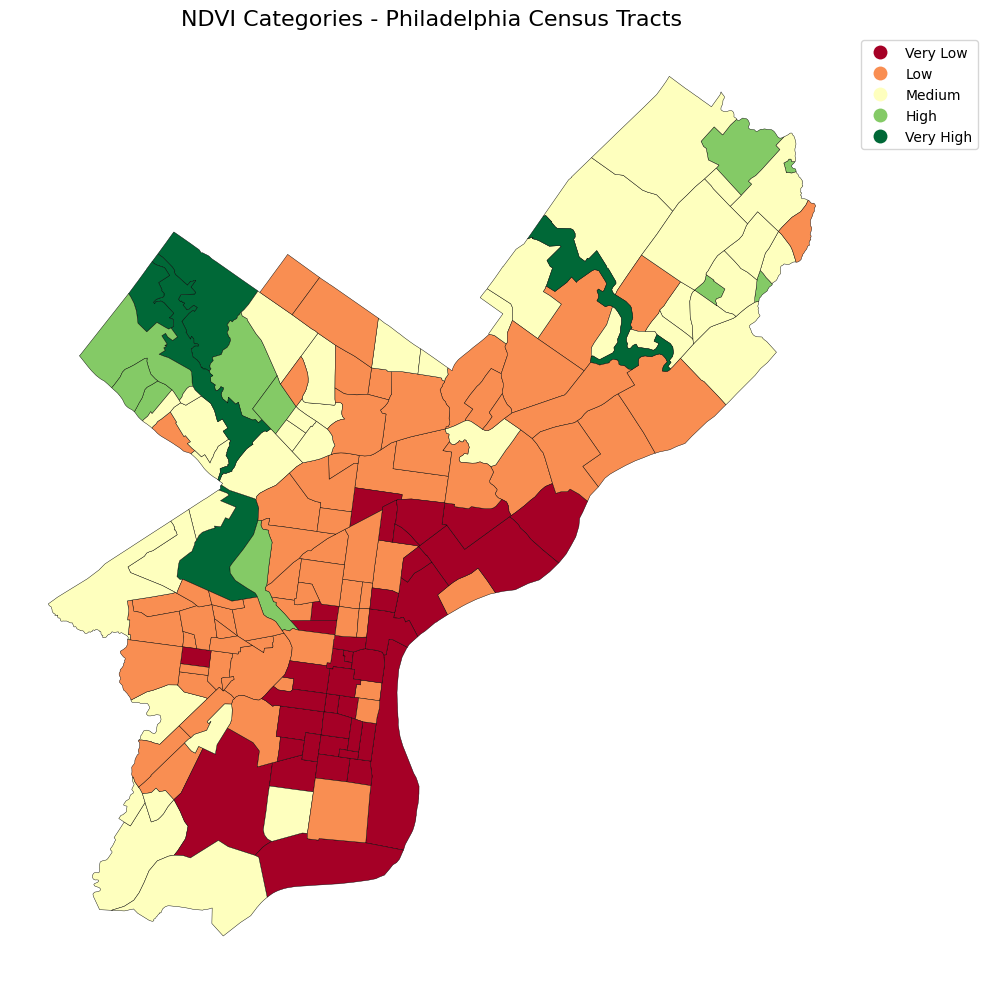

In [87]:
# Diagnostic Map
import pandas as pd
# Classify tracts into categories
def classify_ndvi(score):
    if score < 0.05:
        return 'Very Low (<0.2)'
    elif score < 0.2:
        return 'Low (0.2-0.4)'
    elif score < 0.3:
        return 'Medium (0.4-0.6)'
    elif score < 0.4:
        return 'High (0.6-0.8)'
    else:
        return 'Very High (>0.8)'

tracts['ndvi_category'] = tracts['ndvi_score'].apply(classify_ndvi)

##TO Order categories

# Example: NDVI categories
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

tracts['ndvi_category'] = pd.cut(
    tracts['ndvi_score'],  # your normalized NDVI 0-1
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Make sure the category is ordered
tracts['ndvi_category'] = tracts['ndvi_category'].cat.reorder_categories(labels, ordered=True)

# Plot categories
fig, ax = plt.subplots(figsize=(10, 10))
tracts.plot(
    column='ndvi_category',
    categorical=True,
    legend=True,
    cmap='RdYlGn',
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)
ax.set_title('NDVI Categories - Philadelphia Census Tracts', fontsize=16)
ax.axis('off')

plt.tight_layout()
plt.savefig('../../outputs/ndvi_categories.png', dpi=300, bbox_inches='tight')
plt.show()

In [102]:
tracts[tracts['Name'].str.contains('PASSYUNK', case=False, na=False)]


,Name,geometry,ndvi_mean,ndvi_median,ndvi_std,ndvi_count,ndvi_score,tree_count,area_sqmi,tree_density,tree_score
105,WEST_PASSYUNK,"POLYGON ((2687671.164 227872.85, 2690474.474 2...",0.073341,0.064519,0.030065,660,0.071007,0.0,0.229645,0.0,0.0
107,EAST_PASSYUNK,"POLYGON ((2692095.99 225898.045, 2692411.37 22...",0.066130,0.061240,0.023429,679,0.051117,0.0,0.236161,0.0,0.0
152,PASSYUNK_SQUARE,"POLYGON ((2695723.128 228111.539, 2695664.839 ...",0.086122,0.074120,0.049893,903,0.106255,0.0,0.312995,0.0,0.0


### 3. Load park data & calculate distance to neaerest park for each census tract centroid

In [124]:
# Use OSMnx to get park locations in Philadelphia
phillygdf_84 = phillygdf.to_crs("EPSG:4326")  # OSMnx requires lat/lon CRS

parks = ox.features_from_polygon(
    phillygdf_84.unary_union,
    tags={'leisure': ['park', 'playground','dog_park', 'garden', 'pitch', 'recreation_ground']}
)



print(f"✅ Found {len(parks)} parks in Philadelphia")
print(f"   Total park area: {parks.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres

# Preview
print("\nSample parks:")
print(parks[['name', 'leisure']].head(10))


# Keep only essential columns for saving
parks_clean = parks[['geometry', 'name', 'leisure']].copy()

# Handle any NaN names
parks_clean['name'] = parks_clean['name'].fillna('Unnamed Park')

# Save cleaned version
parks_clean.to_file("../../data/philadelphia_parks_osm.geojson", driver='GeoJSON')

print(f"✅ Saved {len(parks_clean)} parks to data/philadelphia_parks_osm.geojson")

# But keep the full version for analysis
print(f"\nFull parks dataset has {len(parks.columns)} columns")
print(f"Available columns: {parks.columns.tolist()[:10]}...")  # Show first 10


C:\Users\kalmanj\AppData\Local\Temp\ipykernel_9524\21739700.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  phillygdf_84.unary_union,


✅ Found 3624 parks in Philadelphia
   Total park area: 0 acres

Sample parks:
                                                                name leisure
element id                                                                  
node    357275889                                   Awbury Arboretum    park
        357276509                         Belfield Recreation Center    park
        357283944  Lonnie Young Recreation Center of East Germantown    park
        357288965                          Shepard Recreation Center    park
        357289574                                Harpers Hollow Park    park
        357294803                                           Lee Park    park
        357313728                     Starr Garden Recreation Center    park
        357315908                                  Tacony Creek Park    park
        357319279                        Waterview Recreation Center    park
        357320161                                     Wharton Square    par

C:\Users\kalmanj\AppData\Local\Temp\ipykernel_9524\21739700.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"   Total park area: {parks.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres


✅ Saved 3624 parks to data/philadelphia_parks_osm.geojson

Full parks dataset has 112 columns
Available columns: ['geometry', 'ele', 'gnis:feature_id', 'leisure', 'name', 'wikidata', 'alt_name', 'sport', 'old_name', 'access']...


In [129]:
# ### Calculate distance to neaerest park for each census tract centroid
from scipy.spatial import cKDTree
from shapely.geometry import Point

In [130]:
# Get census tract centroids
tracts = tracts.to_crs(2272)
parks = parks.to_crs(2272)

tract_centroids = tracts.copy()
tract_centroids['geometry'] = tracts.geometry.centroid

# Get park boundaries (or centroids for small parks)
park_points = parks.geometry.representative_point()

# Build spatial index
park_coords = np.array([(p.x, p.y) for p in park_points])
tree = cKDTree(park_coords)

# Find nearest park for each census tract
tract_coords = np.array([(p.x, p.y) for p in tract_centroids.geometry])
distances, indices = tree.query(tract_coords)

# Add distance (in feet for EPSG:2272)
tracts['park_distance_ft'] = distances

### 3.1 Convert distances to proximity scores (0-1 scale)

In [131]:
# Common approach: inverse distance with maximum threshold
# 800m (1/2 mile) = ~2625 feet as maximum reasonable walking distance

# Min-max normalize park proximity so closer parks get higher scores
min_dist = tracts['park_distance_ft'].min()
max_dist = tracts['park_distance_ft'].max()

tracts['park_proximity_score'] = 1 - (tracts['park_distance_ft'] - min_dist) / (max_dist - min_dist)



# Alternative: Use exponential decay
# tracts['park_proximity_score'] = np.exp(-tracts['park_distance_ft'] / 1312)  # 400m in feet

### 4. Tree Canopy Raster Analysis

✅ Loaded 2,480 trees
   Columns: ['objectid', 'fcode', 'geometry']


<Axes: >

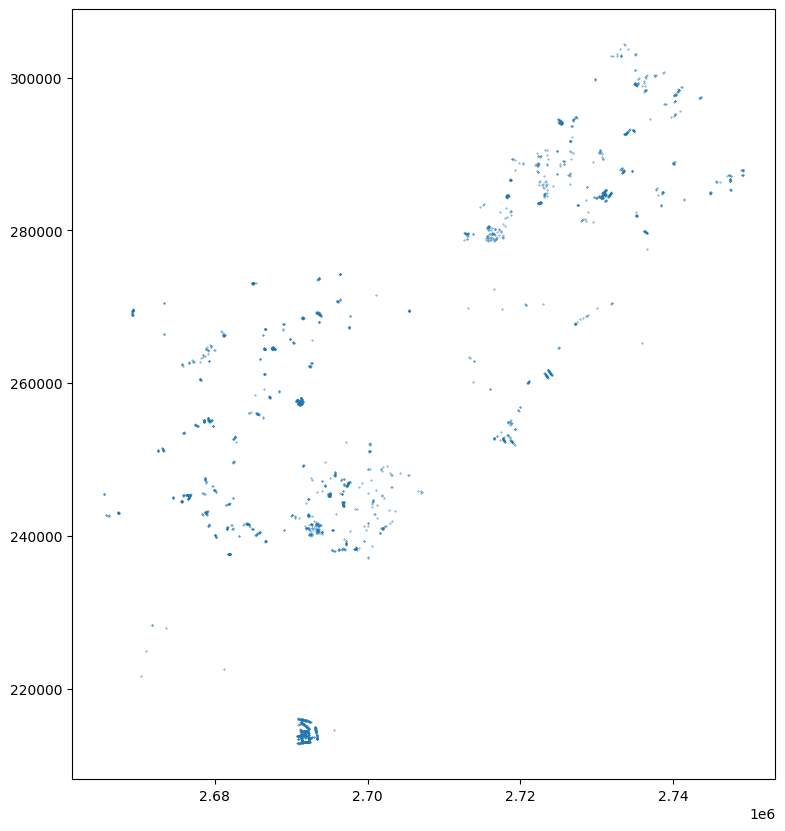

In [134]:
# Load tree point data
trees = gpd.read_file("../../data/ppr_tree_canopy_points_2015.geojson")

# Convert to EPSG:2272 to match tracts
trees = trees.to_crs('EPSG:2272')

print(f"✅ Loaded {len(trees):,} trees")
print(f"   Columns: {trees.columns.tolist()}")

# Quick check - visualize
trees.plot(markersize=0.1, figsize=(10, 10))

### 4.1 Count trees per census tract

In [135]:
tracts = tracts.to_crs(2272)
parks = trees.to_crs(2272)
# Spatial join - which tract is each tree in?
trees_with_tract = gpd.sjoin(trees, tracts[['Name', 'geometry']], how='left', predicate='within')

# Count trees per tract
tree_counts = trees_with_tract.groupby('Name').size().reset_index(name='tree_count')

# Merge back to tracts
tracts = tracts.merge(tree_counts, on='Name', how='left')

# Fill NaN (tracts with no trees) with 0
tracts['tree_count'] = tracts['tree_count'].fillna(0)

print(f"Trees per neighborhood summary:")
print(tracts['tree_count'].describe())

Trees per neighborhood summary:
count    158.000000
mean      15.696203
std       43.569362
min        0.000000
25%        0.000000
50%        1.000000
75%       12.000000
max      438.000000
Name: tree_count, dtype: float64


### 4.2 Calculate & Normalize Tree Density Score (0-1 scale)

In [136]:
# Option A: Trees per square mile
tracts['area_sqmi'] = tracts.geometry.area / (5280**2)  # sq ft to sq miles
tracts['tree_density'] = tracts['tree_count'] / tracts['area_sqmi']

In [137]:
# Use min-max normalization
tree_min = tracts['tree_density'].min()
tree_max = tracts['tree_density'].max()

tracts['tree_score'] = (tracts['tree_density'] - tree_min) / (tree_max - tree_min)

# Or use quantile-based (if you have outliers)
# tracts['tree_score'] = tracts['tree_density'].rank(pct=True)

print(f"Tree score range: {tracts['tree_score'].min():.3f} to {tracts['tree_score'].max():.3f}")

Tree score range: 0.000 to 1.000


## Concot Greenspace Index by combining NDVI, Park Proximity, and Tree Density Scores equal weight

In [138]:
# Now combine all three components
tracts['greenspace_index'] = (
    tracts['ndvi_score'] * 0.33 +
    tracts['park_proximity_score'] * 0.33 +
    tracts['tree_score'] * 0.34
)

### Notes

In [69]:
# Save final greenspace index
tracts.to_file("../../data/philadelphia_greenspace_index.geojson", driver='GeoJSON')

print(f"✅ Greenspace index saved!")
print(f"   Tracts: {len(tracts)}")
print(f"   Mean score: {tracts['greenspace_index'].mean():.3f}")
print(f"   Range: {tracts['greenspace_index'].min():.3f} to {tracts['greenspace_index'].max():.3f}")

✅ Greenspace index saved!
   Tracts: 158
   Mean score: 0.348
   Range: 0.158 to 0.643


In [71]:
print("="*60)
print("GREENSPACE INDEX COMPLETE")
print("="*60)
print(tracts['greenspace_index'].describe())

print(f"\nTop 5 Greenest Tracts:")
print(tracts.nlargest(5, 'greenspace_index')[['Name', 'greenspace_index']])

print(f"\nLeast Green Tracts:")
print(tracts.nsmallest(5, 'greenspace_index')[['Name', 'greenspace_index']])


GREENSPACE INDEX COMPLETE
count    158.000000
mean       0.347921
std        0.110296
min        0.157708
25%        0.256411
50%        0.330577
75%        0.431007
max        0.642643
Name: greenspace_index, dtype: float64

Top 5 Greenest Tracts:
                 Name  greenspace_index
84      SPRING_GARDEN          0.642643
87   WISSAHICKON_PARK          0.614379
156     DEARNLEY_PARK          0.600718
109     WEST_PARKSIDE          0.580839
60           YORKTOWN          0.576562

Least Green Tracts:
               Name  greenspace_index
143  FRANKLIN_MILLS          0.157708
46           TACONY          0.163793
83       HOLMESBURG          0.169755
47           MODENA          0.173805
15       TORRESDALE          0.174240


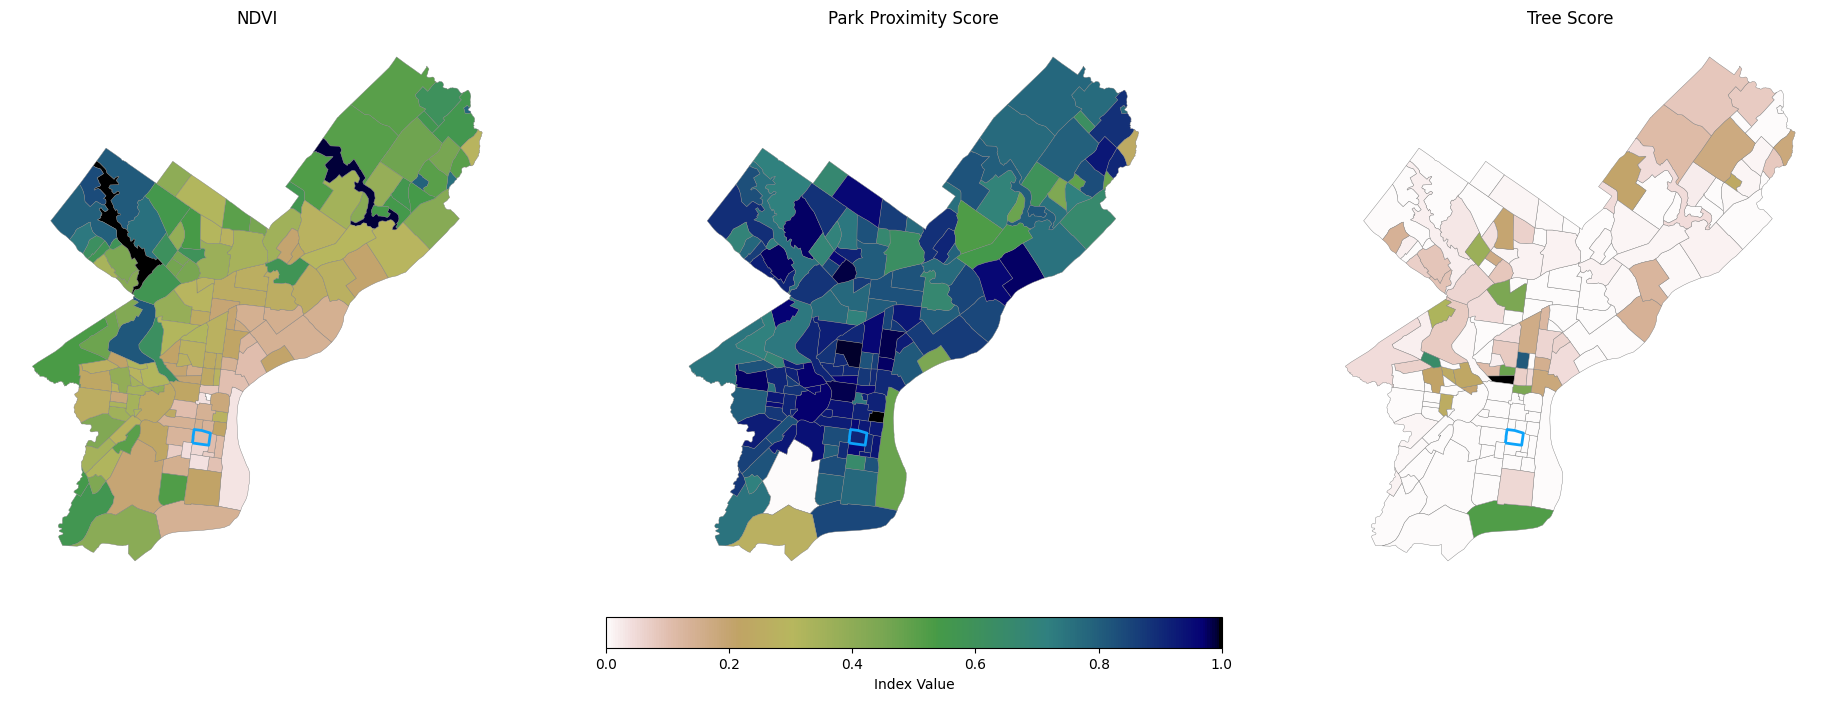

In [141]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as colors

# --- SHARED COLORMAP AND NORMALIZATION ---
vmin = min(
    tracts["ndvi_score"].min(),
    tracts["park_proximity_score"].min(),
    tracts["tree_score"].min()
)

vmax = max(
    tracts["ndvi_score"].max(),
    tracts["park_proximity_score"].max(),
     tracts["tree_score"].max()
)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "gist_earth_r"

# --- GET EAST PASSYUNK POLYGON ---
east_passyunk = tracts[tracts["Name"] == "PASSYUNK_SQUARE"]

# --- CREATE FIGURE ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
ax1, ax2, ax3 = axes


# -------------------------
# MAP 1 – Cartway Density
# -------------------------
tracts.plot(
    column="ndvi_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax1
)

# Highlight East Passyunk
east_passyunk.boundary.plot(ax=ax1, color="#0CA3FA", linewidth=2)

ax1.set_title("NDVI")
ax1.axis("off")


# -------------------------
# MAP 2 – Bike Lane Index
# -------------------------
east_passyunk = tracts[tracts["Name"] == "PASSYUNK_SQUARE"]

tracts.plot(
    column="park_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax2
)

east_passyunk.boundary.plot(ax=ax2, color="#0CA3FA", linewidth=2)

ax2.set_title("Park Proximity Score")
ax2.axis("off")


# -------------------------
# MAP 3 – Sidewalk Index
# -------------------------
east_passyunk = tracts[tracts["Name"] == "PASSYUNK_SQUARE"]

tracts.plot(
    column="tree_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax3
)

east_passyunk.boundary.plot(ax=ax3, color="#0CA3FA", linewidth=2)

ax3.set_title("Tree Score")
ax3.axis("off")


# -------------------------
# SHARED COLORBAR
# -------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Index Value")

plt.show()


In [121]:
tracts.park_proximity_score

0      0.474217
1      0.176640
2      0.933018
3      0.829104
4      0.426313
         ...   
153    0.681224
154    0.896339
155    0.867188
156    0.942014
157    0.906333
Name: park_proximity_score, Length: 158, dtype: float64